In [1]:
import os
import shutil
import zipfile
from pathlib import Path

from hyp3_sdk import HyP3
from hyp3lib.dem import prepare_dem_geotiff
from mintpy.cli import tsview
from shapely.geometry import box
from osgeo import gdal, ogr

In [2]:
hyp3 = HyP3('https://hyp3-volcsarvatory-test.asf.alaska.edu')

batch = hyp3.find_jobs(name='uwg')
batch.download_files('uwg')

  0%|                                                                                                                                                                               | 0/28 [00:00<?, ?it/s]
NISAR_L2_OD_GUNW_009_113_D_079_4005_DHDH_A_20260105T011332_20260105T011407_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:   0%|                                       | 0/169303295 [00:00<?, ?it/s]
NISAR_L2_OD_GUNW_009_113_D_079_4005_DHDH_A_20260105T011332_20260105T011407_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:   6%|██                               | 10.0M/161M [00:01<00:15, 10.3MB/s]
NISAR_L2_OD_GUNW_009_113_D_079_4005_DHDH_A_20260105T011332_20260105T011407_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:  12%|████                             | 20.0M/161M [00:01<00:11, 13.1MB/s]
NISAR_L2_OD_GUNW_009_113_D_079_4005_DHDH_A_20260105T011332_20260105T011407_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:  19%|██████▏                          | 30.0M/161M [00:


NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251224T011332_20251224T011406_X05009_N_F_A_001.zip:   0%|                                       | 0/165672668 [00:00<?, ?it/s]
NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251224T011332_20251224T011406_X05009_N_F_A_001.zip:   6%|██                               | 10.0M/158M [00:01<00:14, 10.4MB/s]
NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251224T011332_20251224T011406_X05009_N_F_A_001.zip:  13%|████▏                            | 20.0M/158M [00:01<00:12, 11.6MB/s]
NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251224T011332_20251224T011406_X05009_N_F_A_001.zip:  19%|██████▎                          | 30.0M/158M [00:02<00:10, 12.9MB/s]
NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251224T011332_20251224T011406_X05009_N_F_A_001.zip:  25%|████████▎                        | 40.0M/158M [00


NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.zip:   0%|                                       | 0/159918749 [00:00<?, ?it/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.zip:   7%|██▏                              | 10.0M/153M [00:00<00:11, 13.3MB/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.zip:  13%|████▎                            | 20.0M/153M [00:01<00:09, 14.8MB/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.zip:  20%|██████▍                          | 30.0M/153M [00:02<00:08, 14.4MB/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.zip:  26%|████████▋                        | 40.0M/153M [00


NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20260105T011332_20260105T011407_X05009_N_F_A_001.zip:   0%|                                       | 0/161754005 [00:00<?, ?it/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20260105T011332_20260105T011407_X05009_N_F_A_001.zip:   6%|██▏                              | 10.0M/154M [00:00<00:10, 13.8MB/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20260105T011332_20260105T011407_X05009_N_F_A_001.zip:  13%|████▎                            | 20.0M/154M [00:01<00:08, 15.8MB/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20260105T011332_20260105T011407_X05009_N_F_A_001.zip:  19%|██████▍                          | 30.0M/154M [00:01<00:07, 18.2MB/s]
NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20260105T011332_20260105T011407_X05009_N_F_A_001.zip:  26%|████████▌                        | 40.0M/154M [00


NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:   0%|                                       | 0/170250057 [00:00<?, ?it/s]
NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:   6%|██                               | 10.0M/162M [00:01<00:19, 8.31MB/s]
NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:  12%|████                             | 20.0M/162M [00:01<00:12, 12.1MB/s]
NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:  18%|██████                           | 30.0M/162M [00:02<00:09, 15.4MB/s]
NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20260117T011333_20260117T011407_X05009_N_F_A_001.zip:  25%|████████▏                        | 40.0M/162M [00

[PosixPath('uwg/NISAR_L2_OD_GUNW_009_113_D_079_4005_DHDH_A_20260105T011332_20260105T011407_20260117T011333_20260117T011407_X05009_N_F_A_001.zip'),
 PosixPath('uwg/NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20260105T011332_20260105T011407_X05009_N_F_A_001.zip'),
 PosixPath('uwg/NISAR_L2_OD_GUNW_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_20251212T011331_20251212T011406_X05009_N_F_A_001.zip'),
 PosixPath('uwg/NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251224T011332_20251224T011406_X05009_N_F_A_001.zip'),
 PosixPath('uwg/NISAR_L2_OD_GUNW_008_113_D_079_4005_DHDH_A_20251224T011332_20251224T011406_20260117T011333_20260117T011407_X05009_N_F_A_001.zip'),
 PosixPath('uwg/NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251212T011331_20251212T011406_X05009_N_F_A_001.zip'),
 PosixPath('uwg/NISAR_L2_OD_GUNW_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_20251224T011332_20251224T01

In [3]:
# Set your target directory here
target_dir = Path("uwg")

# 1. Unzip all files
for file in target_dir.glob("*.zip"):
    with zipfile.ZipFile(file, "r") as zip_ref:
        zip_ref.extractall(target_dir)

# 2. Delete non-h5 files (and zip files)
for path in target_dir.rglob("*"):
    if path.is_file():
        # Keep only HDF5 files
        if path.suffix.lower() not in ['.h5']:
            path.unlink()

In [2]:
bbox=[-99.5, 19.2, -98.8, 19.9]

prepare_dem_geotiff('uwg/dem.tif', ogr.CreateGeometryFromWkb(box(*bbox).wkb), epsg_code=4326, pixel_size=0.001)

'uwg/dem.tif'

In [2]:
work_dir = Path('uwg/MintPy')
work_dir.mkdir(parents=True, exist_ok=True)
shutil.copy('config.txt', 'uwg/MintPy/mintpy_config.txt')
config_path = Path('uwg/MintPy/mintpy_config.txt')

In [3]:
import mintpy.cli.smallbaselineApp as smallbaselineApp

args = f'{config_path} --work-dir={work_dir}'
smallbaselineApp.main(args.split())


___________________________________________________________

  /##      /## /##             /##     /#######
 | ###    /###|__/            | ##    | ##__  ##
 | ####  /#### /## /#######  /######  | ##  \ ## /##   /##
 | ## ##/## ##| ##| ##__  ##|_  ##_/  | #######/| ##  | ##
 | ##  ###| ##| ##| ##  \ ##  | ##    | ##____/ | ##  | ##
 | ##\  # | ##| ##| ##  | ##  | ## /##| ##      | ##  | ##
 | ## \/  | ##| ##| ##  | ##  |  ####/| ##      |  #######
 |__/     |__/|__/|__/  |__/   \___/  |__/       \____  ##
                                                 /##  | ##
                                                |  ######/
   Miami InSAR Time-series software in Python    \______/
          MintPy 1.6.3, 2025-11-24
___________________________________________________________

--RUN-at-2026-07-12 20:16:27.163945--
Current directory: /media/mfangaritasr/1F98B5915C2BDCB8/test_minthi3
Run routine processing with smallbaselineApp.py on steps: ['load_data', 'modify_network', 'reference_point',

/home/mfangaritasr/anaconda3/envs/mintpy4nisar/lib/python3.12/site-packages/mintpy/objects/stack.py:1059: RuntimeWarning: Mean of empty slice
  dmean[r0:r1, :] = np.nanmean(data, axis=0)


 
random select pixel with coherence > 0.97
	based on coherence file: avgSpatialCoh.h5
y/x: (203, 649)
Add/update ref_x/y attribute to file: /media/mfangaritasr/1F98B5915C2BDCB8/test_minthi3/uwg/MintPy/inputs/ifgramStack.h5
{'REF_Y': '203', 'REF_X': '649', 'REF_LAT': '2184280.0', 'REF_LON': '499320.0'}
touch avgSpatialCoh.h5
touch maskConnComp.h5


******************** step - quick_overview ********************
Input data seems to be geocoded. Lookup file not needed.

temporal_average.py /media/mfangaritasr/1F98B5915C2BDCB8/test_minthi3/uwg/MintPy/inputs/ifgramStack.h5 --dataset unwrapPhase -o /media/mfangaritasr/1F98B5915C2BDCB8/test_minthi3/uwg/MintPy/avgPhaseVelocity.h5 --update
--------------------------------------------------
update mode: ON
1) output file /media/mfangaritasr/1F98B5915C2BDCB8/test_minthi3/uwg/MintPy/avgPhaseVelocity.h5 NOT exist.
run or skip: run.
calculate the temporal average of unwrapPhase in file /media/mfangaritasr/1F98B5915C2BDCB8/test_minthi3/uwg/MintPy/in

tsview.py uwg/MintPy/timeseries_ramp.h5 -d=uwg/MintPy/inputs/geometryGeo.h5 --ref-yx 750 450 --ref-date 20251025 -v -7 7
open timeseries file: timeseries_ramp.h5
No lookup table (longitude or rangeCoord) found in files.
data   coverage in y/x: (0, 0, 921, 971)
subset coverage in y/x: (0, 0, 921, 971)
data   coverage in lat/lon: (447360.0, 2200560.0, 521040.0, 2122880.0)
subset coverage in lat/lon: (447360.0, 2200560.0, 521040.0, 2122880.0)
------------------------------------------------------------------------
reference point in y/x: [750, 450]
reference point in lat/lon: (2140520.0, 483400.0)
estimate deformation model with the following assumed time functions:
    polynomial : 1
    periodic   : []
    stepDate   : []
    polyline   : []
    exp        : {}
    log        : {}
reading timeseries from file uwg/MintPy/timeseries_ramp.h5
reference to pixel: [750, 450]
reference to date: 20251025
read mask from file: maskTempCoh.h5
data    range: [np.float32(-20.767439), np.float32(14.4

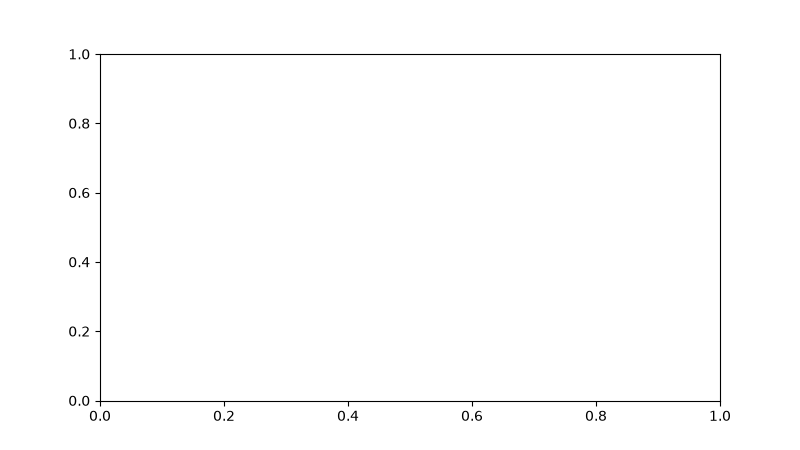

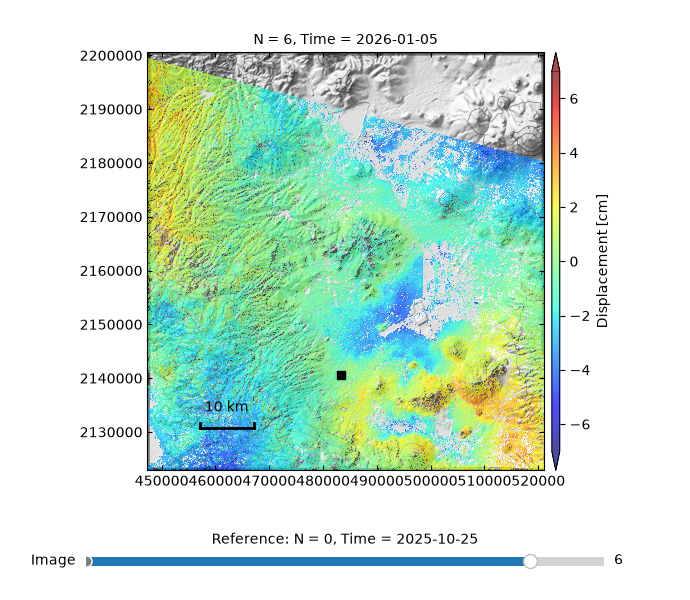

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt

tsview.main(
    [
        f'{work_dir}/timeseries_ramp.h5',
        f'-d={work_dir}/inputs/geometryGeo.h5',
        f'--ref-yx',
        f'750',
        f'450',
        f'--ref-date',
        f'20251025',
        f'-v',
        f'-7',
        f'7'
    ]
)